# Propagation of the jitters to LUXE's IP

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/EuXFEL-Lattice/lattices/')
from longlist_2024_07_04 import i1
from longlist_2024_07_04 import l1
from longlist_2024_07_04 import l2
from longlist_2024_07_04 import l3
from longlist_2024_07_04 import cl
from longlist_2024_07_04 import tl2
from longlist_2024_07_04 import tl34_sa2
from longlist_2024_07_04 import t1
from longlist_2024_07_04 import sase2
from longlist_2024_07_04 import t3
from longlist_2024_07_04 import t5
from longlist_2024_07_04 import t5_new
from longlist_2024_07_04 import t5d
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex/')
import plotXsuite
import plotOcelot
import plotCompareOcelotXsuite
from xsuite_scripts import XTD8_no_DBA_match_with_no_R56 as XTD8
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd

import pandas as _pd
import ocelot as _ocl

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_07_07"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Propagation/" + date + "_EuXFEL_plot"

In [2]:
def getClosestElement(tw, s_target):
    delta = _np.inf
    closest_name = ''
    closest_s = 0
    for name, s in zip(tw.name, tw.s):
        if _np.abs(s_target-s) < delta:
            delta=_np.abs(s_target-s)
            closest_name = name
            closest_s = s
    return closest_name, closest_s

In [3]:
sequence = [tl2, tl34_sa2, t1, sase2, t3]
for i, line in enumerate(sequence):
    for elem in line.cell:
        if type(elem) == _ocl.Drift:
            elem.id = elem.id + '_' +str(line).split(' ')[1].strip("'").split('.')[-1] 
    if i == 0:
        cell = line.cell
    else:
        cell += line.cell
lat = _ocl.MagneticLattice(cell)
tws = _ocl.twiss(lat, sequence[0].tws0)

In [4]:
lat.save_as_py_file("jupyter_notebooks/test_tl_t3.py", tws0=sequence[0].tws0)

In [5]:
from jupyter_notebooks import test_tl_t3

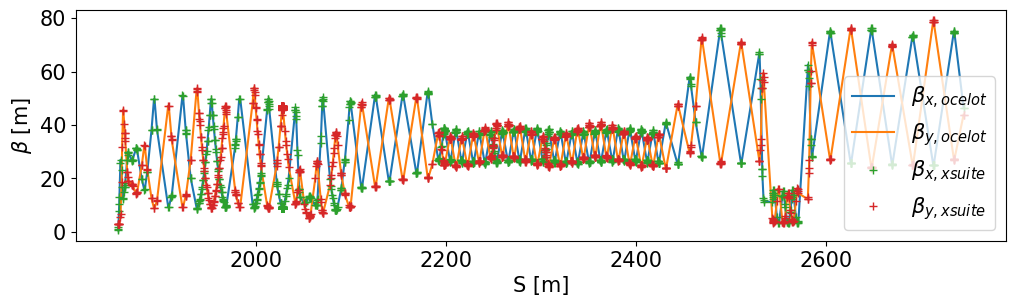

In [6]:
plotCompareOcelotXsuite.checkBetaForLine(test_tl_t3, figsize=[12, 3])
# _plt.ylim(-5, 60)
# _plt.xlim(1970, 2000)

In [7]:
XTD1_XTD3_Xsuite = _bd.Convert.Ocelot2Xsuite(test_tl_t3, y0=2.75, z0=23.2, previousLineList=None)

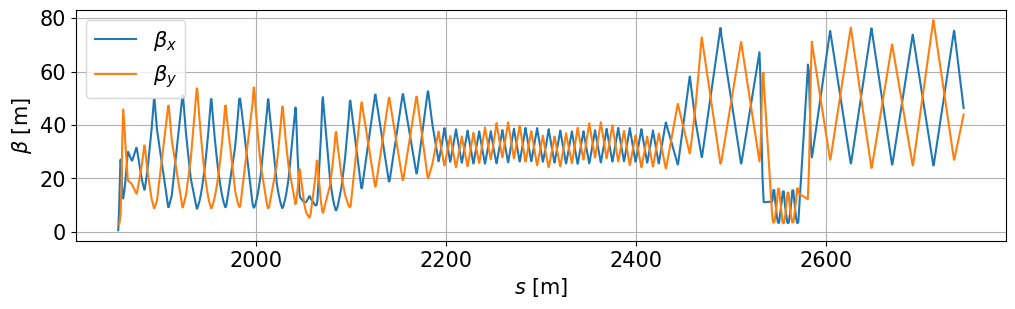

In [8]:
plotXsuite.plotBeta(XTD1_XTD3_Xsuite, 'line_from_ocelot', 'XTL_to_XTD5', gmadfolder='jupyter_notebooks/gmad_files/', lattice=False)

In [44]:
def getMatrix(srange=None):
    line_1 = XTD1_XTD3_Xsuite.env.line_from_ocelot
    tw_1 = line_1.twiss(**XTD1_XTD3_Xsuite.tws0)
    surv_1 = line_1.survey(**XTD1_XTD3_Xsuite.surv0)
    line_2 = XTD8.env.XTD8
    tw_2 = line_2.twiss(**XTD8.tws0)
    
    indexlist = []
    for i, s in enumerate(tw_1.s):
        if srange[0] < s+XTD1_XTD3_Xsuite.s0 < srange[1]:
            if surv_1.element_type[i] == 'BeamPositionMonitor':
                indexlist.append(i)
    
    R11=[]
    R12=[]
    for index in indexlist:
        rmat_1 = tw_1.get_R_matrix(tw_1.name[index], tw_1.name[-1])
        rmat_2 = tw_2.get_R_matrix(tw_2.name[0], 'IP.LUXE.T20')
        r_total = _np.dot(rmat_2, rmat_1)
        R11.append(r_total[0,0])
        R12.append(r_total[0,1])
    return R11, R12

In [45]:
R11, R12 = getMatrix(srange=[2075, 2150])

In [55]:
X = _np.random.normal(loc=0, scale=3e-6, size=1000)
XP = _np.random.normal(loc=0, scale=3e-6, size=1000)

In [58]:
X_Meas = []
for r11, r12 in zip(R11, R12):
    x_meas = _np.std(X*r11+XP*r12)
    X_Meas.append(x_meas)

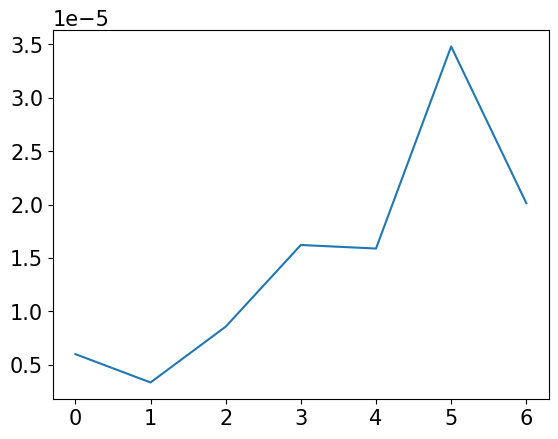

In [59]:
_plt.plot(X_Meas)

In [301]:
line_1 = XTD1_XTD3_Xsuite.env.line_from_ocelot
tw_1 = line_1.twiss(**XTD1_XTD3_Xsuite.tws0)
rmat_1 = tw_1.get_R_matrix(tw_1.name[-2], tw_1.name[-1])
df_1 = _pd.DataFrame(rmat_1)

In [302]:
line_2 = XTD8.env.XTD8
tw_2 = line_2.twiss(**XTD8.tws0)
rmat_2 = tw_2.get_R_matrix(tw_2.name[0], 'IP.LUXE.T20')
df_2 = _pd.DataFrame(rmat_2)

In [303]:
df_total = _pd.DataFrame(_np.dot(rmat_2, rmat_1))

In [304]:
df_total.round(4)

,0,1,2,3,4,5
0,-0.3134,-2.8156,0.0000,0.0000,-0.0,-0.0
1,-0.0809,-3.9173,0.0000,0.0000,0.0,0.0
2,0.0000,-0.0000,-0.3618,5.2999,-0.0,-0.0
3,0.0000,0.0000,0.0439,-3.4076,0.0,0.0
4,0.0000,0.0000,0.0000,0.0000,1.0,0.0
5,-0.0000,-0.0000,-0.0000,0.0000,0.0,1.0


In [300]:
df_total.iloc[4:, 4:]

,4,5
4,1.000000e+00,-0.000398
5,4.440769e-16,1.000000


BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


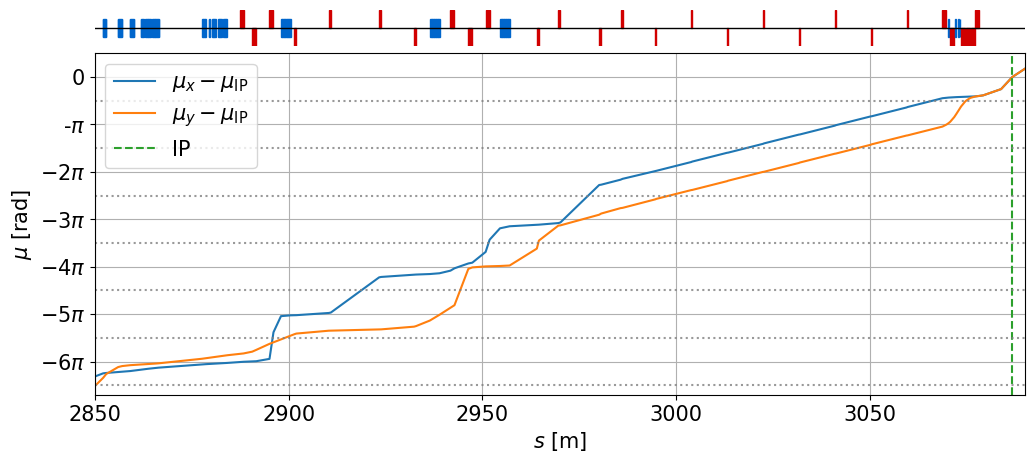

In [10]:
plotXsuite.plotPhaseAdvance(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/', 
                            addMachine=False, addMarker=False, figsize=[12, 5])
tw = XTD8.env.XTD8.twiss(**XTD8.tws0)
_plt.axvline(tw.s[-5]+XTD8.s0, color='C2', label='IP', ls='--')
_plt.legend([r"$\mu_x - \mu_{\rm IP}$", r"$\mu_y - \mu_{\rm IP}$", "IP"])
for i in range(1,11,1):
    _plt.axhline(-i+0.5, ls=':', color='gray', alpha=0.8)
_plt.ylim([-6.7, 0.5])
plotXsuite.addMachineLattice(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/')
_plt.xlim([2850, 3090])
_plt.savefig("{}_Phase_advance_XTD8.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [11]:
def getCorrelatedS(xsuiteInput, linename, mu='mux', n=-1):
    twiss = xsuiteInput.env[linename].twiss(**xsuiteInput.tws0)
    mu_IP = getattr(twiss, mu)[-5]
    mu_diff_correl = _np.inf
    mu_min = None
    s_min = None
    for mu, s in zip(getattr(twiss, mu), twiss.s):
        mu_diff_IP = (mu-mu_IP)*2
        if _np.abs(n-mu_diff_IP) < mu_diff_correl:
            mu_diff_correl = _np.abs(n-mu_diff_IP)
            mu_min = mu_diff_IP
            s_min = s + xsuiteInput.s0
    return s_min, mu_min

def getAllCorelatedS(xsuiteInput, linename, mu='mux', n_range=_np.linspace(-9, -1, 9)):
    mu_list = []
    s_list = []
    for n in n_range:
        s_min, mu_min = getCorrelatedS(xsuiteInput, linename, mu=mu, n=n)
        mu_list.append(mu_min)
        s_list.append(s_min)
    return s_list, mu_list

def getAllBPMPosAndMu(xsuiteInput, linename):
    twiss = xsuiteInput.env[linename].twiss(**xsuiteInput.tws0)
    survey = xsuiteInput.env[linename].survey(**xsuiteInput.surv0)
    slist = []
    namelist = []
    muxlist = []
    muylist = []
    for i, Type in enumerate(survey.element_type):
        if Type == "Quadrupole":
            slist.append(survey.s[i]+xsuiteInput.s0)
            namelist.append(survey.name[i])
            muxlist.append((twiss.mux[i]-twiss.mux[-5])*2)
            muylist.append((twiss.muy[i]-twiss.muy[-5])*2)
    return slist, namelist, muxlist, muylist

def getClosestBPMPosAndMu(xsuiteInput, linename, s_target):
    twiss = xsuiteInput.env[linename].twiss(**xsuiteInput.tws0)
    survey = xsuiteInput.env[linename].survey(**xsuiteInput.surv0)
    slist = []
    namelist = []
    muxlist = []
    muylist = []
    for i, Type in enumerate(survey.element_type):
        if Type == "Quadrupole":
            slist.append(survey.s[i]+xsuiteInput.s0)
            namelist.append(survey.name[i])
            muxlist.append((twiss.mux[i]-twiss.mux[-5])*2)
            muylist.append((twiss.muy[i]-twiss.muy[-5])*2)
    s_diff = _np.inf
    s_min = None
    name_min = None
    mux_min = None
    muy_min = None
    for s, name, mux, muy in zip(slist, namelist, muxlist, muylist):
        if _np.abs(s-s_target) < s_diff:
            s_diff = _np.abs(s-s_target)
            s_min = s
            name_min = name
            mux_min = mux
            muy_min = muy
    return s_min, name_min, mux_min, muy_min

def getAllClosestBPM(xsuiteInput, linename, slist):
    s_list = []
    name_list = []
    mux_list = []
    muy_list = []
    for s in slist:
        s_min, name_min, mux_min, muy_min = getClosestBPMPosAndMu(xsuiteInput, linename, s)
        s_list.append(s_min)
        name_list.append(name_min)
        mux_list.append(mux_min)
        muy_list.append(muy_min)
    return s_list, name_list, mux_list, muy_list

def getMatrixCoeffFromNamelist(xsuiteInput, linename, name_list, i=0, j=0):
    twiss = xsuiteInput.env[linename].twiss(**xsuiteInput.tws0)
    R11 = []
    for name in name_list:
        rmat = twiss.get_R_matrix(name, 'IP.LUXE.T20')
        R11.append(rmat[i,j])
    return R11

In [12]:
slist, namelist, muxlist, muylist = getAllBPMPosAndMu(XTD8, 'XTD8')

In [13]:
s_list_correl_x, mu_list_x = getAllCorelatedS(XTD8, 'XTD8', mu='mux', n_range=_np.linspace(-9, -1, 9))
s_list_correl_y, mu_list_y = getAllCorelatedS(XTD8, 'XTD8', mu='muy', n_range=_np.linspace(-9, -1, 9))
s_list_correl_xp, mu_list_xp = getAllCorelatedS(XTD8, 'XTD8', mu='mux', n_range=_np.linspace(-8.5, -0.5, 9))
s_list_correl_yp, mu_list_yp = getAllCorelatedS(XTD8, 'XTD8', mu='muy', n_range=_np.linspace(-8.5, -0.5, 9))

In [14]:
s_list_bpm_correl_x, name_list_x, mux_list_x, muy_list_x = getAllClosestBPM(XTD8, 'XTD8', s_list_correl_x)
s_list_bpm_correl_y, name_list_y, mux_list_y, muy_list_y = getAllClosestBPM(XTD8, 'XTD8', s_list_correl_y)
s_list_bpm_correl_xp, name_list_xp, mux_list_xp, muy_list_xp = getAllClosestBPM(XTD8, 'XTD8', s_list_correl_xp)
s_list_bpm_correl_yp, name_list_yp, mux_list_yp, muy_list_yp = getAllClosestBPM(XTD8, 'XTD8', s_list_correl_yp)

BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


(2850.0, 3093.0)

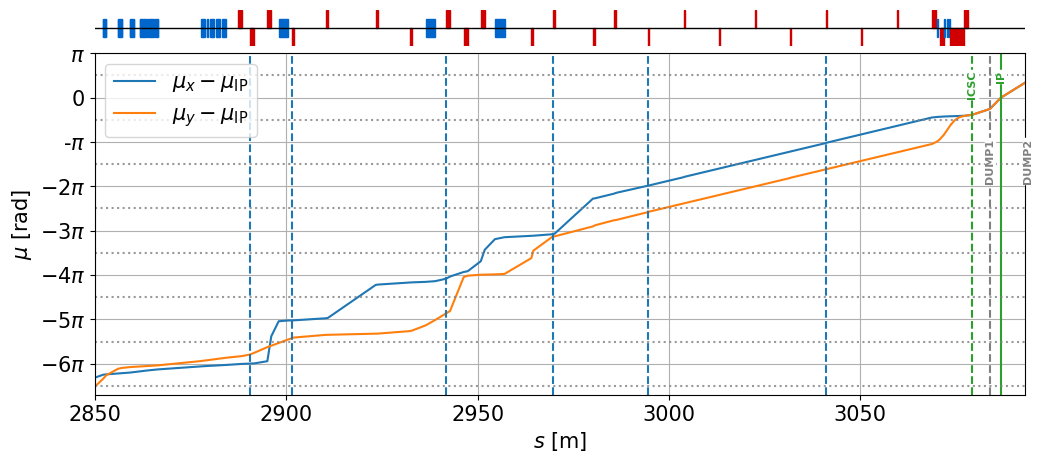

In [28]:
plotXsuite.plotPhaseAdvance(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/', 
                            addMachine=False, addMarker=True, figsize=[12, 5], ylim=[-6.7, 1])
_plt.legend([r"$\mu_x - \mu_{\rm IP}$", r"$\mu_y - \mu_{\rm IP}$"], loc=2)
for i in range(0,11,1):
    _plt.axhline(-i+0.5, ls=':', color='gray', alpha=0.8)
for s in s_list_bpm_correl_x:
    _plt.axvline(s, ls='--', color='C0')
plotXsuite.addMachineLattice(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/')
_plt.xlim([2850, 3093])

BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


(2850.0, 3093.0)

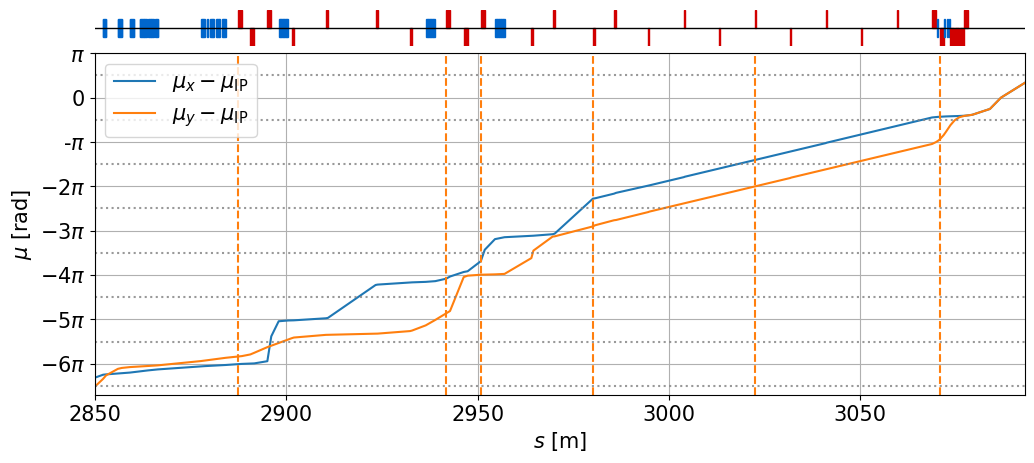

In [30]:
plotXsuite.plotPhaseAdvance(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/', 
                            addMachine=False, addMarker=False, figsize=[12, 5], ylim=[-6.7, 1])
_plt.legend([r"$\mu_x - \mu_{\rm IP}$", r"$\mu_y - \mu_{\rm IP}$"], loc=2)
for i in range(0,11,1):
    _plt.axhline(-i+0.5, ls=':', color='gray', alpha=0.8)
for s in s_list_bpm_correl_y:
    _plt.axvline(s, ls='--', color='C1')
plotXsuite.addMachineLattice(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/')
_plt.xlim([2850, 3093])

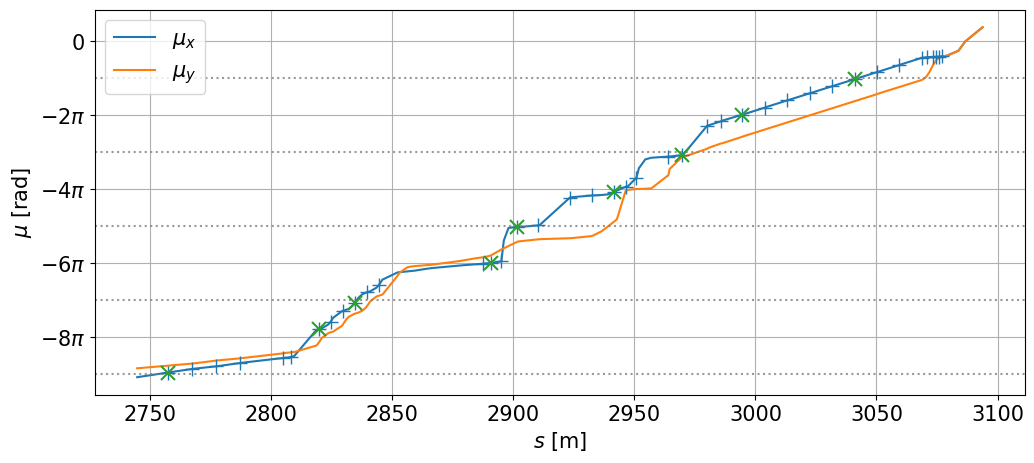

In [29]:
plotXsuite.plotPhaseAdvance(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/', 
                            addMachine=False, addMarker=False, figsize=[12, 5])
for i in range(1,11,2):
    _plt.axhline(-i, ls=':', color='gray', alpha=0.8)
_plt.plot(slist, muxlist, ls='', marker='+', color='C0', markersize=10)
_plt.plot(s_list_bpm_correl_x, mux_list_x, ls='', marker='x', color='C2', markersize=10, markeredgewidth=1.5)

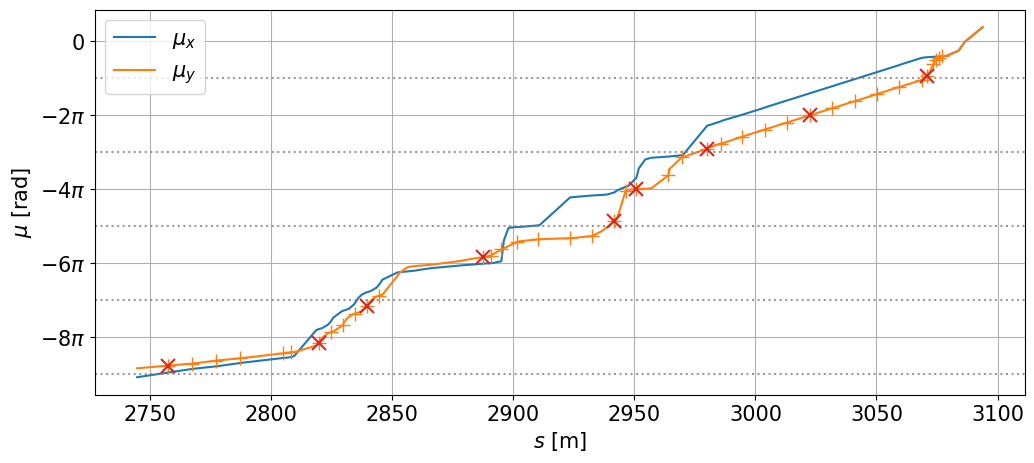

In [16]:
plotXsuite.plotPhaseAdvance(XTD8, 'XTD8', 'XTD8', gmadfolder='jupyter_notebooks/gmad_files/', 
                            addMachine=False, addMarker=False, figsize=[12, 5])
for i in range(1,11,2):
    _plt.axhline(-i, ls=':', color='gray', alpha=0.8)
_plt.plot(slist, muylist, ls='', marker='+', color='C1', markersize=10)
_plt.plot(s_list_bpm_correl_y, muy_list_y, ls='', marker='x', color='C3', markersize=10, markeredgewidth=1.5)

In [278]:
R11_x = getMatrixCoeffFromNamelist(XTD8, 'XTD8', name_list_x, i=0, j=0)
R33_y = getMatrixCoeffFromNamelist(XTD8, 'XTD8', name_list_y, i=2, j=2)
R21_x = getMatrixCoeffFromNamelist(XTD8, 'XTD8', name_list_x, i=1, j=0)
R43_y = getMatrixCoeffFromNamelist(XTD8, 'XTD8', name_list_y, i=3, j=2)

In [275]:
for i in range(len(R11_x)):
    print(name_list_x[i], round(s_list_bpm_correl_x[i], 2), round(R11_x[i], 4))

QE.2756.T5 2757.23 -0.3134
QH.2819.T5 2819.58 0.9696
QM.2834.T5 2834.57 -1.0448
QH.2890.T8 2890.61 0.1826
QF.2906.T8 2901.46 0.1392
QH.2941.T8 2941.76 1.0071
QF.2961.T8 2969.61 -1.0784
QE.1.T8::0 2994.63 0.3353
QE.2.T8::2 3040.95 -0.5914


In [274]:
for i in range(len(R33_y)):
    print(name_list_y[i], round(s_list_bpm_correl_y[i], 2), round(R33_y[i], 4))

QE.2756.T5 2757.23 -0.3618
QH.2819.T5 2819.58 1.0749
QM.2839.T5 2839.57 -1.079
QH.2887.T8 2887.34 0.3678
QH.2941.T8 2941.76 -0.688
QH.2946.T8 2950.84 0.2121
QF.2981.T8 2980.13 -0.5174
QE.2.T8::1 3022.42 0.3001
QH.12.T20 3070.74 -0.6625


In [279]:
for i in range(len(R21_x)):
    print(name_list_xp[i], round(s_list_bpm_correl_xp[i], 2), round(R21_x[i], 4))

QH.2807.T5 2808.15 -0.0809
QM.2824.T5 2824.57 -0.1829
QH.2844.T5 2844.58 -0.1306
QH.2892.T8 2895.06 -0.7798
QF.2920.T8 2923.34 1.3373
QH.2946.T8 2950.84 0.5276
QF.2981.T8 2980.13 -0.8886
QE.2.T8::1 3022.42 -0.1977
QH.11.T20 3068.74 -0.0948


In [280]:
for i in range(len(R43_y)):
    print(name_list_yp[i], round(s_list_bpm_correl_yp[i], 2), round(R43_y[i], 4))

QH.2804.T5 2805.01 0.0439
QM.2829.T5 2829.57 0.043
QH.2844.T5 2844.58 -0.0358
QH.2892.T8 2895.06 -0.0365
QH.2941.T8 2941.76 -0.0111
QF.2955.T8 2964.05 -1.3847
QE.1.T8::0 2994.63 -0.1753
QE.1.T8::3 3050.21 -0.205
QH.14.T20::0 3074.77 -0.3336
